## Gen AI MissInformation Dataset
### Logistic Regression 

### import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings as w
import math

w.filterwarnings("ignore")

### Load Dataset

In [2]:
df = pd.read_csv('/kaggle/input/gen-ai-misinformation-detection-datase-20242025/generative_ai_misinformation_dataset.csv')
df.head()

,id,post_id,platform,timestamp,date,time,month,weekday,country,city,...,sentiment_score,toxicity_score,model_signature,detected_synthetic_score,embedding_sim_to_facts,factcheck_verdict,external_factchecks_count,source_domain_reliability,engagement,is_misinformation
0,1,P0001,Reddit,2024-03-06 10:01:00,2024-03-06,10:01:00,March,Wednesday,USA,New York,...,-0.223,0.271,GPT-like,0.829,0.357,TRUE,4,0.543,3899,1
1,2,P0002,Reddit,2025-08-07 18:30:00,2025-08-07,18:30:00,August,Thursday,Germany,Berlin,...,-0.718,0.802,GPT-like,0.075,0.987,FALSE,3,0.199,7651,0
2,3,P0003,Telegram,2024-12-13 03:15:00,2024-12-13,03:15:00,December,Friday,USA,New York,...,-0.989,0.815,GPT-like,0.707,0.729,PARTLY,0,0.074,7260,0
3,4,P0004,Twitter,2024-04-05 07:10:00,2024-04-05,07:10:00,April,Friday,USA,Chicago,...,-0.283,0.116,human,0.863,0.623,FALSE,2,0.064,7454,1
4,5,P0005,Telegram,2024-06-07 06:18:00,2024-06-07,06:18:00,June,Friday,Germany,Hamburg,...,-0.378,0.325,GPT-like,0.730,0.638,PARTLY,0,0.472,8320,0


### Data Spread

In [3]:
df.shape

(500, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         500 non-null    int64  
 1   post_id                    500 non-null    object 
 2   platform                   500 non-null    object 
 3   timestamp                  500 non-null    object 
 4   date                       500 non-null    object 
 5   time                       500 non-null    object 
 6   month                      500 non-null    object 
 7   weekday                    500 non-null    object 
 8   country                    500 non-null    object 
 9   city                       500 non-null    object 
 10  timezone                   500 non-null    object 
 11  author_id                  500 non-null    object 
 12  author_followers           500 non-null    int64  
 13  author_verified            500 non-null    int64  

In [5]:
df.describe()

,id,author_followers,author_verified,text_length,token_count,readability_score,num_urls,num_mentions,num_hashtags,sentiment_score,toxicity_score,detected_synthetic_score,embedding_sim_to_facts,external_factchecks_count,source_domain_reliability,engagement,is_misinformation
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,505745.980000,0.498000,151.638000,35.472000,54.689620,1.490000,2.538000,2.572000,0.003634,0.495948,0.485380,0.518882,2.588000,0.503520,5396.808000,0.536000
std,144.481833,286939.981829,0.500497,74.874504,20.564704,14.991682,1.115522,1.739715,1.718931,0.581028,0.289535,0.293648,0.284176,1.687588,0.288832,2898.501724,0.499202
min,1.000000,146.000000,0.000000,20.000000,3.000000,30.000000,0.000000,0.000000,0.000000,-1.000000,0.001000,0.001000,0.008000,0.000000,0.002000,4.000000,0.000000
25%,125.750000,256249.000000,0.000000,88.000000,18.000000,41.002500,0.000000,1.000000,1.000000,-0.509250,0.255750,0.228500,0.272500,1.000000,0.275000,3049.250000,0.000000
50%,250.500000,493295.000000,0.000000,155.000000,32.000000,55.565000,2.000000,3.000000,3.000000,0.034000,0.504500,0.478000,0.516000,3.000000,0.499500,5686.000000,1.000000
75%,375.250000,768601.500000,1.000000,215.250000,47.250000,68.160000,2.000000,4.000000,4.000000,0.508500,0.746500,0.730750,0.766000,4.000000,0.746000,7892.750000,1.000000
max,500.000000,998936.000000,1.000000,280.000000,92.000000,79.920000,3.000000,5.000000,5.000000,0.999000,0.997000,0.994000,1.000000,5.000000,0.997000,9977.000000,1.000000


In [6]:
df.columns

Index(['id', 'post_id', 'platform', 'timestamp', 'date', 'time', 'month',
       'weekday', 'country', 'city', 'timezone', 'author_id',
       'author_followers', 'author_verified', 'text', 'text_length',
       'token_count', 'readability_score', 'num_urls', 'num_mentions',
       'num_hashtags', 'sentiment_score', 'toxicity_score', 'model_signature',
       'detected_synthetic_score', 'embedding_sim_to_facts',
       'factcheck_verdict', 'external_factchecks_count',
       'source_domain_reliability', 'engagement', 'is_misinformation'],
      dtype='object')

In [7]:
df=df.drop(columns=['post_id','id'])
df.shape

(500, 29)

### EDA

In [13]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

print("NUM : ",numerical_cols)
print("CAT : ",categorical_cols)

NUM :  Index(['author_followers', 'author_verified', 'text_length', 'token_count',
       'readability_score', 'num_urls', 'num_mentions', 'num_hashtags',
       'sentiment_score', 'toxicity_score', 'detected_synthetic_score',
       'embedding_sim_to_facts', 'external_factchecks_count',
       'source_domain_reliability', 'engagement', 'is_misinformation'],
      dtype='object')
CAT :  Index(['platform', 'timestamp', 'date', 'time', 'month', 'weekday', 'country',
       'city', 'timezone', 'author_id', 'text', 'model_signature',
       'factcheck_verdict'],
      dtype='object')


In [14]:
numerical_cols.shape,categorical_cols.shape

((16,), (13,))

In [15]:
df['is_misinformation'].value_counts()

is_misinformation
1    268
0    232
Name: count, dtype: int64

In [16]:
df.isnull().sum()

platform                     0
timestamp                    0
date                         0
time                         0
month                        0
weekday                      0
country                      0
city                         0
timezone                     0
author_id                    0
author_followers             0
author_verified              0
text                         0
text_length                  0
token_count                  0
readability_score            0
num_urls                     0
num_mentions                 0
num_hashtags                 0
sentiment_score              0
toxicity_score               0
model_signature              0
detected_synthetic_score     0
embedding_sim_to_facts       0
factcheck_verdict            0
external_factchecks_count    0
source_domain_reliability    0
engagement                   0
is_misinformation            0
dtype: int64

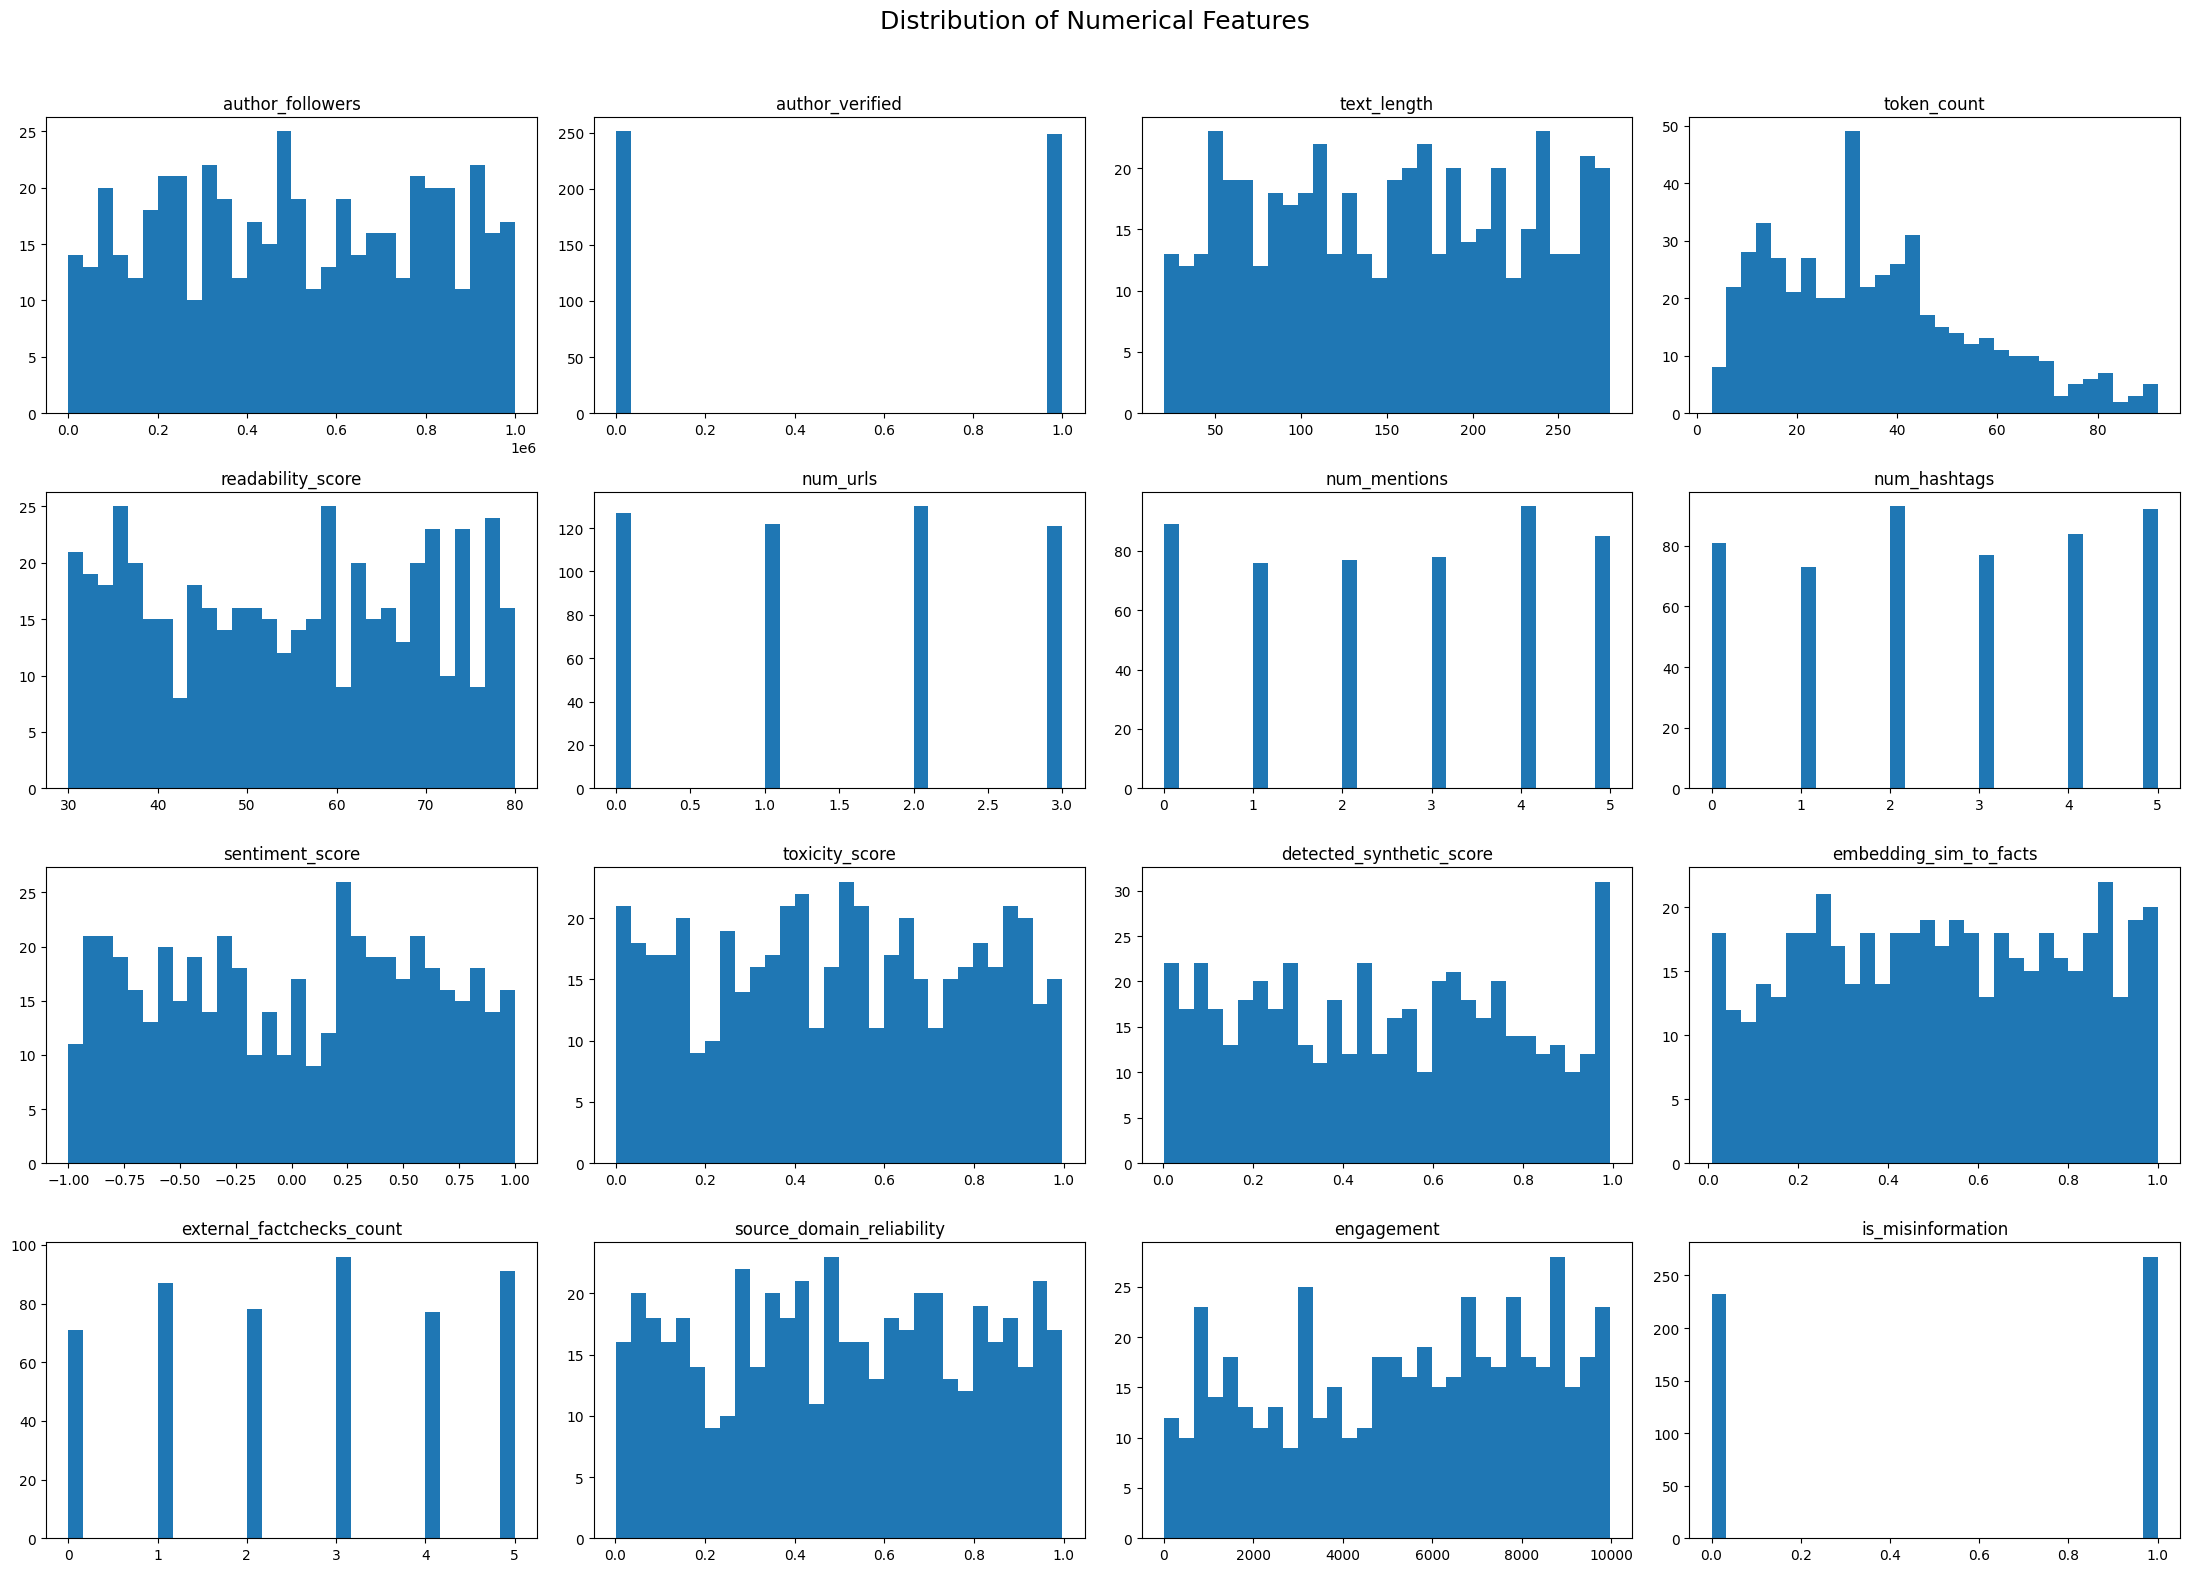

In [17]:
cols = numerical_cols
n = len(cols)

# Choose grid size manually
n_cols = 4                     # 4 plots per row
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4 * n_rows))

axes = axes.flatten()  # make 1D for easy indexing

for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=30)
    axes[i].set_title(col, fontsize=12)
    axes[i].tick_params(axis='both', labelsize=10)

# Remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribution of Numerical Features", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [20]:
part_class = ['author_verified','num_urls','num_mentions','external_factchecks_count','is_misinformation','num_hashtags']
part_class

['author_verified',
 'num_urls',
 'num_mentions',
 'external_factchecks_count',
 'is_misinformation',
 'num_hashtags']

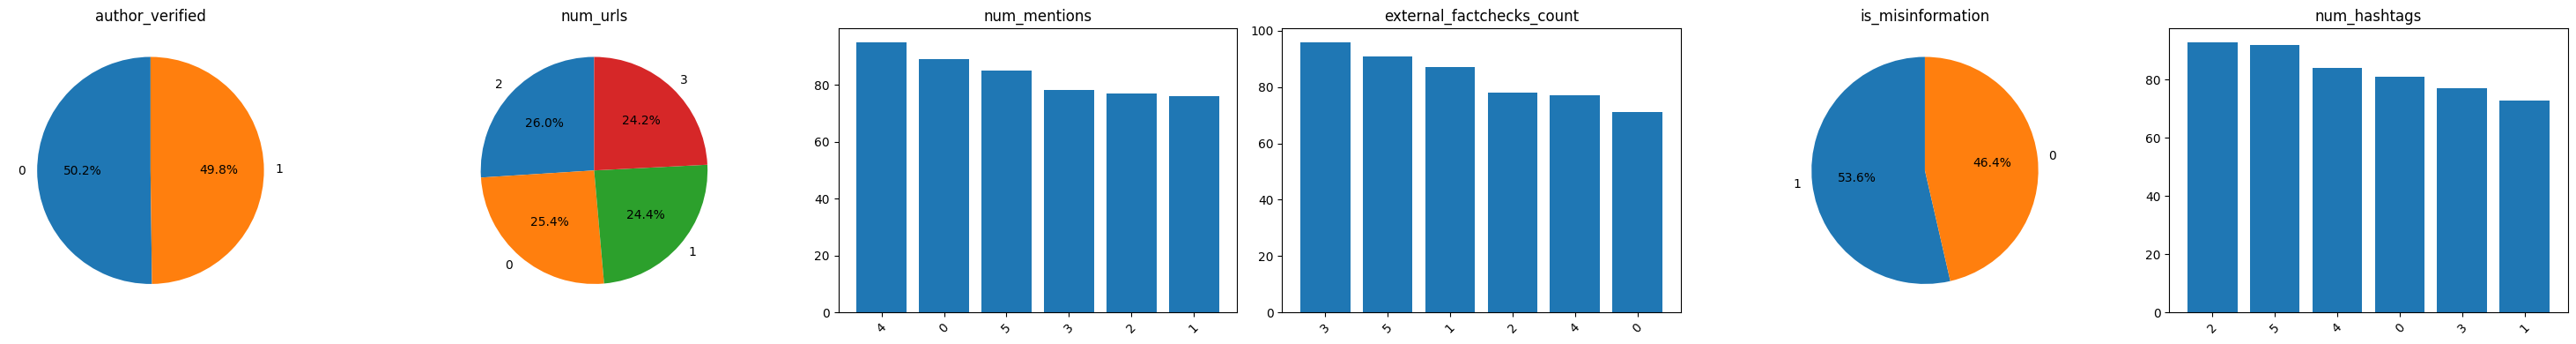

In [33]:
n = len(part_class)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))

# If there's only one subplot, axes is not iterable
if n == 2:
    axes = [axes]

for ax, col in zip(axes, part_class):
    counts = df[col].value_counts(dropna=False)

    if counts.nunique() <= 5:
        # Pie chart for low-cardinality features
        ax.pie(
            counts.values,
            labels=counts.index,
            autopct='%1.1f%%',
            startangle=90
        )
        ax.set_title(col)
    else:
        # Bar chart for non-binary / high-cardinality features
        ax.bar(counts.index.astype(str), counts.values)
        ax.set_title(col)
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [23]:
continuous_val = [col for col in numerical_cols if col not in part_class]
continuous_val

['author_followers',
 'text_length',
 'token_count',
 'readability_score',
 'sentiment_score',
 'toxicity_score',
 'detected_synthetic_score',
 'embedding_sim_to_facts',
 'source_domain_reliability',
 'engagement']

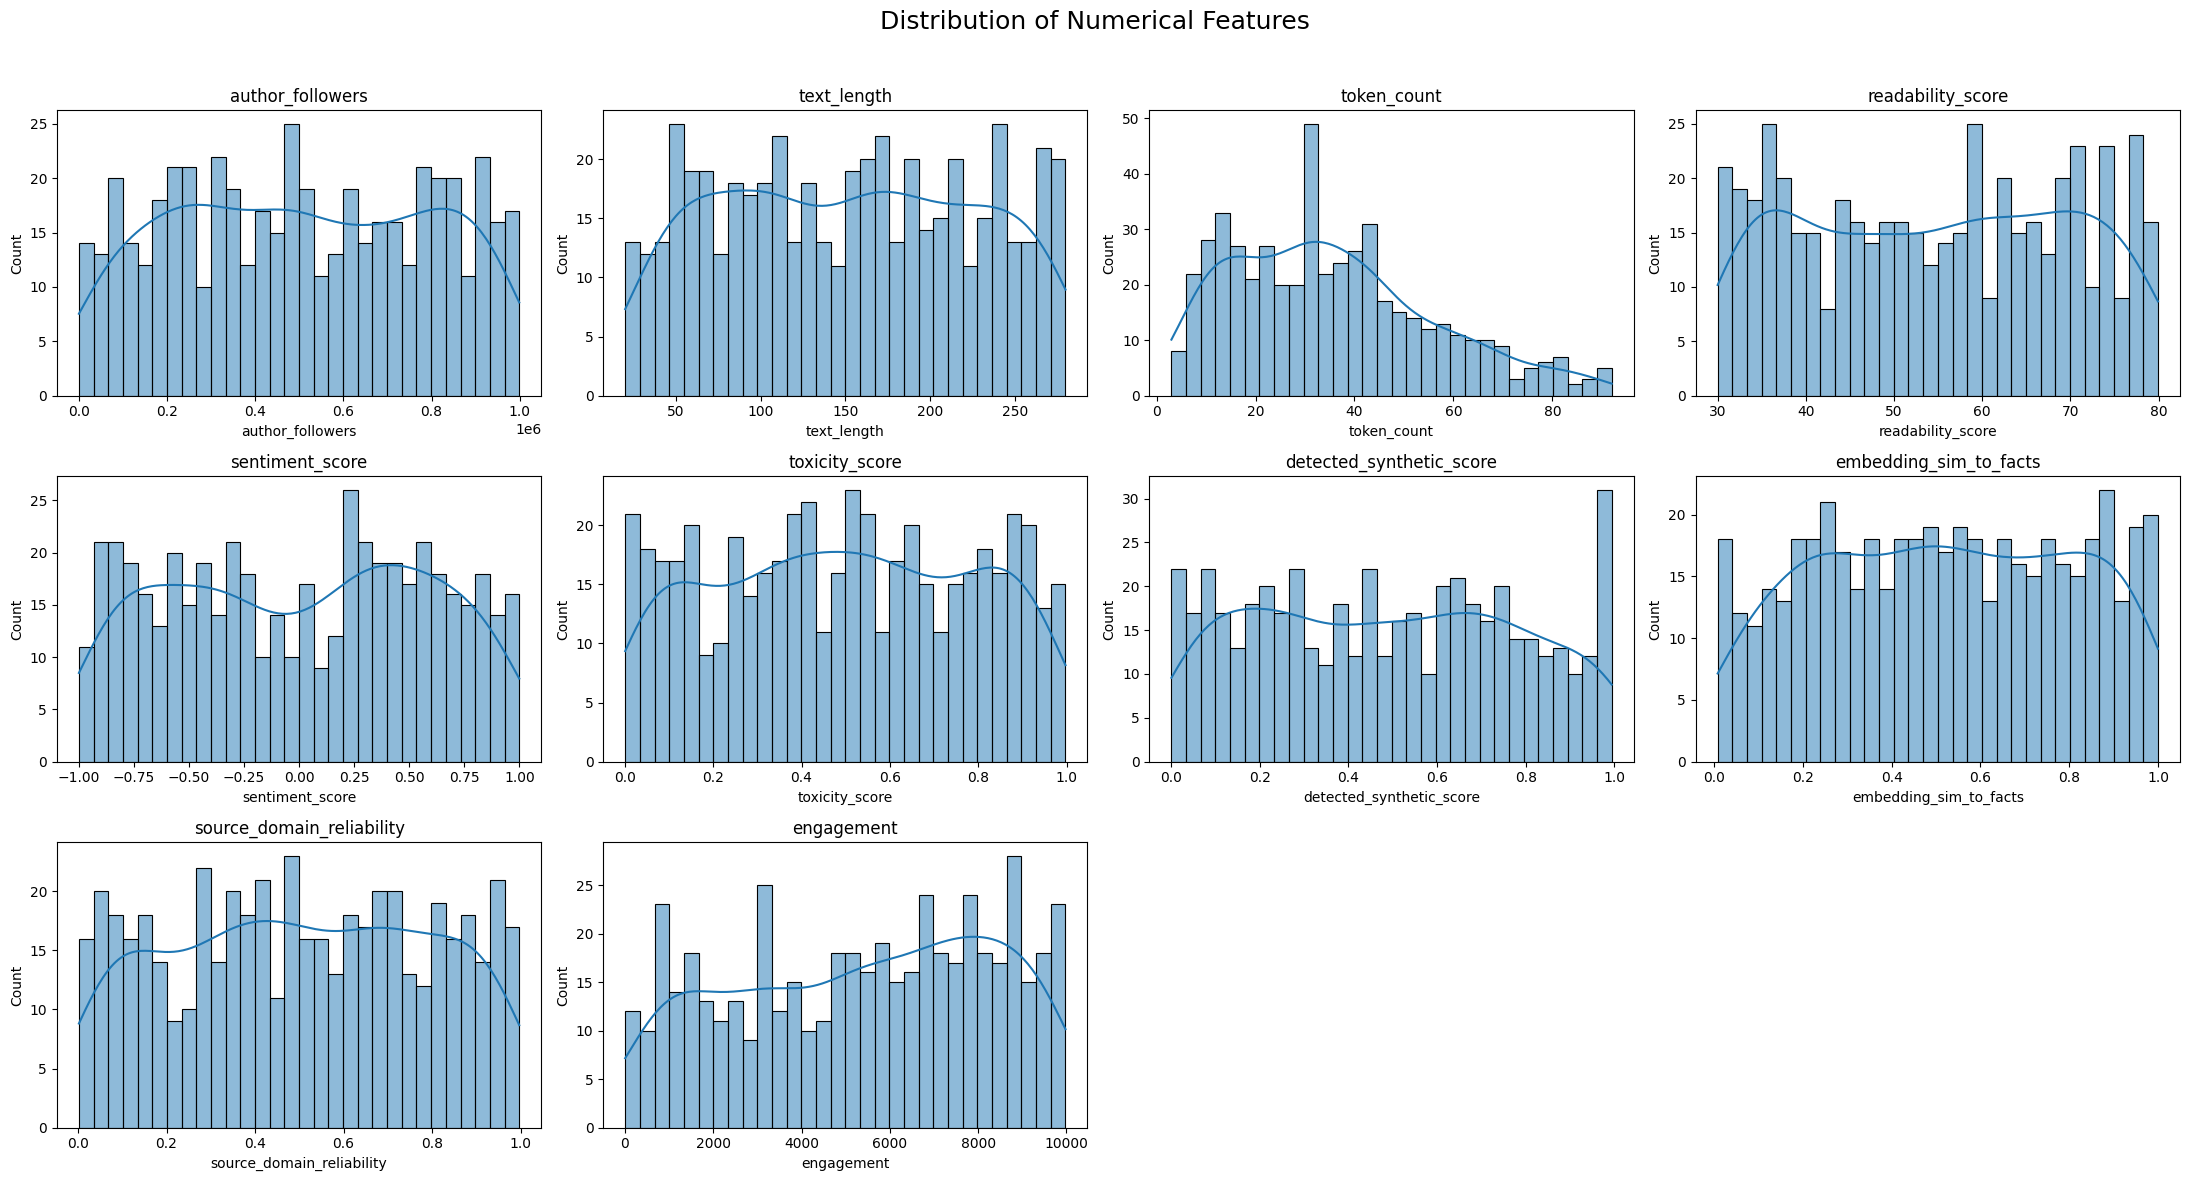

In [38]:


cols = continuous_val
n = len(cols)

# Grid size
n_cols = 4
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=12)
    axes[i].tick_params(axis='both', labelsize=10)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribution of Numerical Features", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()